In [8]:
%matplotlib inline

import mne
from mne.datasets import eegbci
from mne.decoding import CSP
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

mne.set_log_level('WARNING')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Daten laden
subject = 1
runs = [6, 10]
raw_files = eegbci.load_data(subject, runs)
raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in raw_files])

# Elektroden-Namen standardisieren und Positionen setzen
mne.datasets.eegbci.standardize(raw)
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage)

# Filter
raw_filtered = raw.copy().filter(l_freq=8., h_freq=30.)

# Epochen
events, event_id = mne.events_from_annotations(raw_filtered)
epochs = mne.Epochs(raw_filtered, events, event_id={'T1': 2, 'T2': 3},
                    tmin=0.0, tmax=4.0, baseline=None, preload=True)

X = epochs.get_data()
y = epochs.events[:, 2]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (30, 64, 641), y shape: (30,)


In [9]:
#CSP = Common Spatial Patterns
#automatically finds the best spatial filters for two classes instead of manually selecting C3/Cz/C4
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

csp.fit(X, y)

print(f"CSP learned components: {csp.filters_.shape}")
print("Each component is a weighted combination of all 64 channels")

CSP learned components: (64, 64)
Each component is a weighted combination of all 64 channels


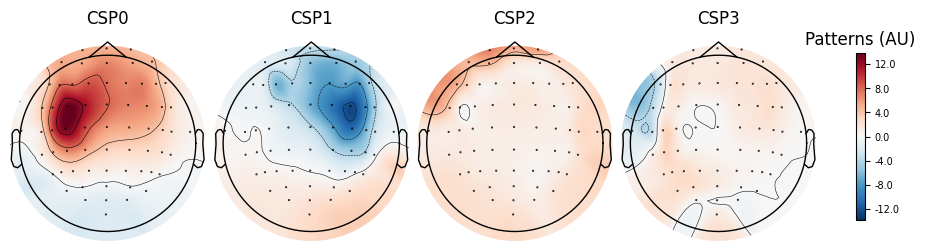

In [11]:
#plotting CSP-pattern
fig = csp.plot_patterns(epochs.info, ch_type='eeg',
                        components=[0, 1, 2, 3],  # nur die 4 besten
                        units='Patterns (AU)', size=1.5,
                        show=False)
plt.savefig(os.path.join(RESULTS_DIR, '05_csp_patterns.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [12]:
# CSP transforms 3D epochs in 2D features
X_csp = csp.transform(X)
print(f"CSP Feature shape: {X_csp.shape}")
#(30, 4) – 30 Epochen, 4 CSP-components as features

#compare classificators
classifiers = {
    'LDA': Pipeline([('lda', LinearDiscriminantAnalysis())]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf'))]),
    'Random Forest': Pipeline([('rf', RandomForestClassifier(n_estimators=100, random_state=42))])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_csp, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name}: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

CSP Feature shape: (30, 4)
LDA: 100.0% ± 0.0%
SVM: 96.7% ± 6.7%
Random Forest: 100.0% ± 0.0%


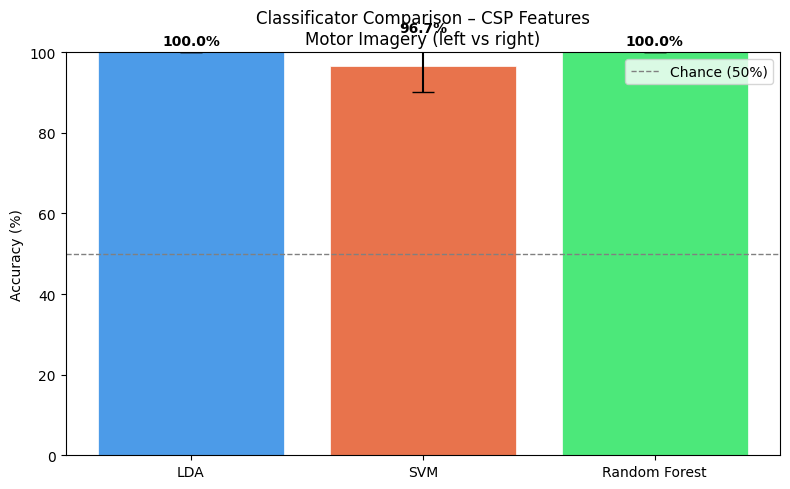

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

names = list(results.keys())
means = [results[k].mean() * 100 for k in names]
stds = [results[k].std() * 100 for k in names]

bars = ax.bar(names, means, yerr=stds, capsize=8,
              color=['#4C9BE8', '#E8734C', '#4CE87A'],
              edgecolor='white', linewidth=0.5)

ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Classificator Comparison – CSP Features\nMotor Imagery (left vs right)')
ax.set_ylim(0, 100)
ax.legend()

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 1,
            f'{mean:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '06_classifier_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [14]:
#more subjects - because of overfitting
subjects = [1, 2, 3, 4, 5]  
all_epochs = []

for subj in subjects:
    raw_files = eegbci.load_data(subj, runs)
    raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in raw_files])
    mne.datasets.eegbci.standardize(raw)
    montage = mne.channels.make_standard_montage('standard_1005')
    raw.set_montage(montage)
    raw_filtered = raw.copy().filter(l_freq=8., h_freq=30.)
    
    events, _ = mne.events_from_annotations(raw_filtered)
    epochs_subj = mne.Epochs(raw_filtered, events, event_id={'T1': 2, 'T2': 3},
                             tmin=0.0, tmax=4.0, baseline=None, preload=True)
    all_epochs.append(epochs_subj)
    print(f"Subjekt {subj}: {len(epochs_subj)} Epochs loaded")

# Alle zusammenführen
epochs_all = mne.concatenate_epochs(all_epochs)
X_all = epochs_all.get_data()
y_all = epochs_all.events[:, 2]

print(f"\nIn total: X shape: {X_all.shape}, y shape: {y_all.shape}")

Subjekt 1: 30 Epochs loaded


Subjekt 2: 30 Epochs loaded


Subjekt 3: 30 Epochs loaded


Subjekt 4: 30 Epochs loaded


Subjekt 5: 30 Epochs loaded

In total: X shape: (150, 64, 641), y shape: (150,)


C:\Users\ameli\AppData\Local\Temp\ipykernel_71040\1735014659.py:20: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_all = mne.concatenate_epochs(all_epochs)


In [15]:
csp_all = CSP(n_components=4, reg=None, log=True, norm_trace=False)
X_csp_all = csp_all.fit_transform(X_all, y_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_all = {}

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_csp_all, y_all, cv=cv, scoring='accuracy')
    results_all[name] = scores
    print(f"{name}: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

LDA: 57.3% ± 4.4%
SVM: 53.3% ± 4.7%
Random Forest: 58.7% ± 10.7%
